In [4]:
import numpy as np
import dpluspy
import pickle

import matplotlib.pyplot as plt

In [5]:
def run_bootstrap(
    in_fnames, 
    out_fname, 
    num_reps=None, 
    weighted=False,
    aggregate=None
):
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)

    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]

    replicates = dpluspy.bootstrapping.get_bootstrap_reps(
        sums, num_reps=num_reps, weighted=weighted, aggregate=aggregate)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    if weighted:
        means = dpluspy.bootstrapping.weighted_means_across_regions(
            sums, aggregate=aggregate)
    else:
        means = dpluspy.bootstrapping.means_across_regions(sums)
    
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
        "replicates": replicates
    }
    with open(out_fname, "wb") as fout:
        pickle.dump(data, fout)
    return

In [6]:
# Bootstrap over stats computed on chromosome arms
fnames = [f"data/sums/arm/arm_stats_chr{j}.pkl" for j in range(1, 23)]
run_bootstrap(fnames, "data/stats/arm_naive.pkl", num_reps=100, 
    weighted=False)
run_bootstrap(fnames, "data/stats/arm_w1.pkl", num_reps=100, 
    weighted=True, aggregate=False)
run_bootstrap(fnames, "data/stats/arm_w2.pkl", 
    num_reps=100, weighted=True, aggregate=True)

In [7]:
fnames = [f"data/sums/interval/interval_stats_chr{j}.pkl" for j in range(1, 23)]
run_bootstrap(fnames, "data/stats/interval_naive.pkl", num_reps=None, 
    weighted=False)
run_bootstrap(fnames, "data/stats/interval_w1.pkl", num_reps=None, 
    weighted=True, aggregate=False)
run_bootstrap(fnames, "data/stats/interval_w2.pkl", 
    num_reps=None, weighted=True, aggregate=True)

In [8]:
fnames = [f"data/sums/interval_overhang/interval_overhang_stats_chr{j}.pkl" 
    for j in range(1, 23)]
run_bootstrap(fnames, "data/stats/overhang_naive.pkl", num_reps=None, 
    weighted=False)
run_bootstrap(fnames, "data/stats/overhang_w1.pkl", num_reps=None, 
    weighted=True, aggregate=False)
run_bootstrap(fnames, "data/stats/overhang_w2.pkl", 
    num_reps=None, weighted=True, aggregate=True)

In [9]:
# Compute average u used in simulation 
fnames = [f"data/sums/arm/arm_stats_chr{j}.pkl" for j in range(1, 23)]
sums = {}
for fname in fnames:
    with open(fname, "rb") as fin:
        chrom_sums = pickle.load(fin)
    sums.update(chrom_sums)
print(len(sums))
u_num = np.sum([sums[key]["mut_facs"][-1] for key in sums])
u_denom = np.sum([sums[key]["denoms"][-1] for key in sums])
u_avg = u_num / u_denom
print(u_num, u_denom)
print(u_avg)
bins = sums[next(iter(sums))]["bins"]
pop_ids = sums[next(iter(sums))]["pop_ids"]

39
7.568523316537882 663209178.0
1.1411970110790418e-08


In [10]:
# Find the exact number of intervals
fnames = [f"data/sums/interval/interval_stats_chr{j}.pkl" for j in range(1, 23)]
sums = {}
for fname in fnames:
    with open(fname, "rb") as fin:
        chrom_sums = pickle.load(fin)
    sums.update(chrom_sums)
print(len(sums))

510


In [11]:
# Compute model expectations for plots
model = dpluspy.inference.compute_bin_stats("scripts/model.yaml", bins=bins,
    u=u_avg, sampled_demes=pop_ids)

In [12]:
# Load all statistics
_, __, arm_naive_ms, arm_naive_vcs = dpluspy.inference.load_stats("data/stats/arm_naive.pkl")
_, __, arm_w1_ms, arm_w1_vcs = dpluspy.inference.load_stats("data/stats/arm_w1.pkl")
_, __, arm_w2_ms, arm_w2_vcs = dpluspy.inference.load_stats("data/stats/arm_w2.pkl")

_, __, interval_naive_ms, interval_naive_vcs = dpluspy.inference.load_stats("data/stats/interval_naive.pkl")
_, __, interval_w1_ms, interval_w1_vcs = dpluspy.inference.load_stats("data/stats/interval_w1.pkl")
_, __, interval_w2_ms, interval_w2_vcs = dpluspy.inference.load_stats("data/stats/interval_w2.pkl")

_, __, overhang_naive_ms, overhang_naive_vcs = dpluspy.inference.load_stats("data/stats/overhang_naive.pkl")
_, __, overhang_w1_ms, overhang_w1_vcs = dpluspy.inference.load_stats("data/stats/overhang_w1.pkl")
_, __, overhang_w2_ms, overhang_w2_vcs = dpluspy.inference.load_stats("data/stats/overhang_w2.pkl")

In [13]:
print(interval_naive_ms[-4])
print(overhang_naive_ms[-4])

[5.79248246e-08 1.23706713e-06 2.06469747e-06 3.47961036e-08
 2.03386495e-06 1.03281010e-06]
[4.44502432e-08 1.05445826e-06 1.71057495e-06 2.53640680e-08
 1.65797288e-06 8.54492565e-07]


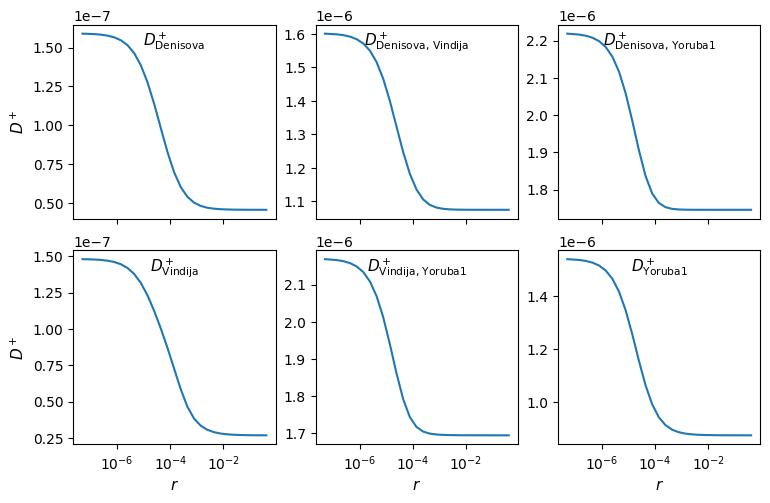

In [14]:
dpluspy.plotting.plot_d_plus_curves(models=model, bins=bins, pop_ids=pop_ids,
    cols=3, ax_size=2.5)

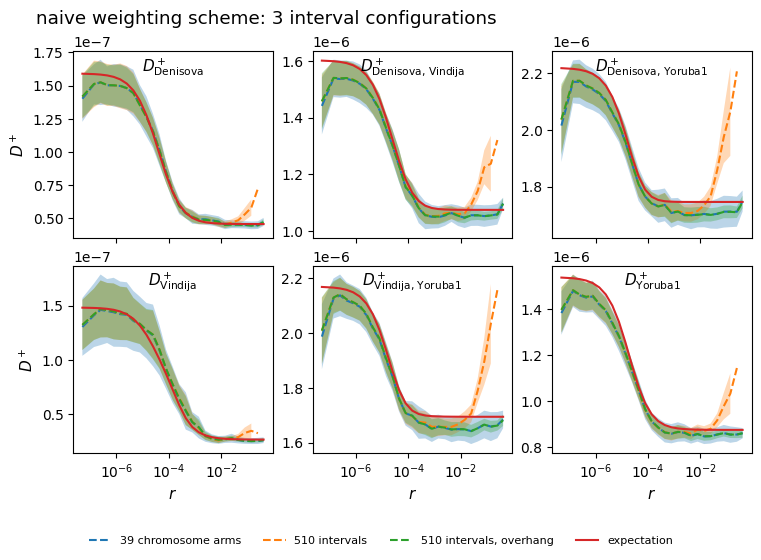

In [15]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_1_naive_weighting.pdf",
    title="naive weighting scheme: 3 interval configurations",
    labels=["39 chromosome arms", "510 intervals", "510 intervals, overhang",
        "expectation"],
    means=[arm_naive_ms, interval_naive_ms, overhang_naive_ms],
    varcovs=[arm_naive_vcs, interval_naive_vcs, overhang_naive_vcs]
)

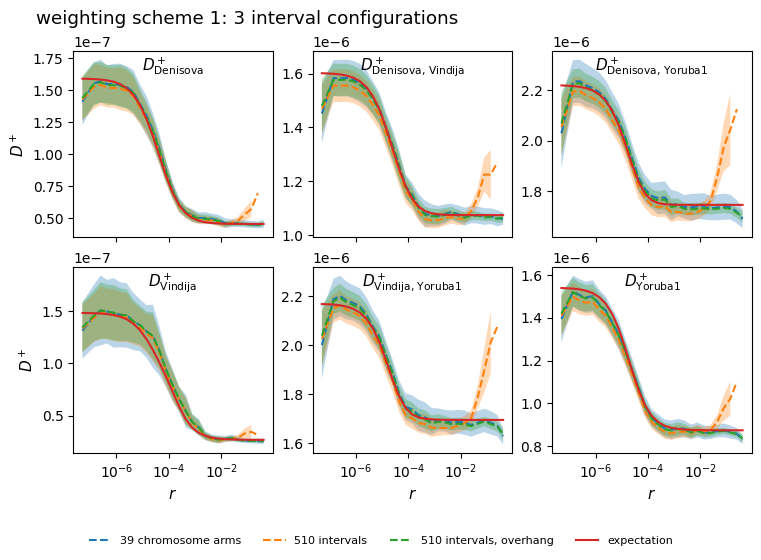

In [16]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_2_weighting_scheme_1.pdf",
    title="weighting scheme 1: 3 interval configurations",
    labels=["39 chromosome arms", "510 intervals", "510 intervals, overhang",
        "expectation"],
    means=[arm_w1_ms, interval_w1_ms, overhang_w1_ms],
    varcovs=[arm_w1_vcs, interval_w1_vcs, overhang_w1_vcs]
)

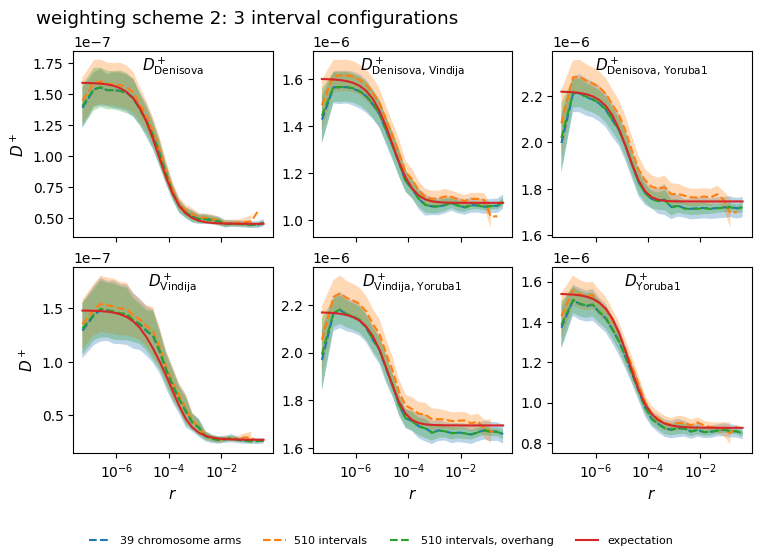

In [17]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_3_weighting_scheme_2.pdf",
    title="weighting scheme 2: 3 interval configurations",
    labels=["39 chromosome arms", "510 intervals", "510 intervals, overhang",
        "expectation"],
    means=[arm_w2_ms, interval_w2_ms, overhang_w2_ms],
    varcovs=[arm_w2_vcs, interval_w2_vcs, overhang_w2_vcs]
)

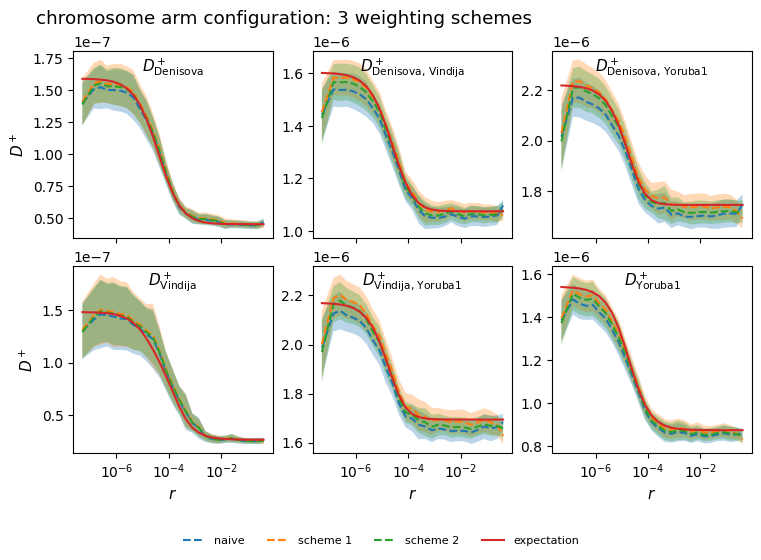

In [18]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_4_arm_config.pdf",
    title="chromosome arm configuration: 3 weighting schemes",
    labels=["naive", "scheme 1", "scheme 2",
        "expectation"],
    means=[arm_naive_ms, arm_w1_ms, arm_w2_ms],
    varcovs=[arm_naive_vcs, arm_w1_vcs, arm_w2_vcs]
)

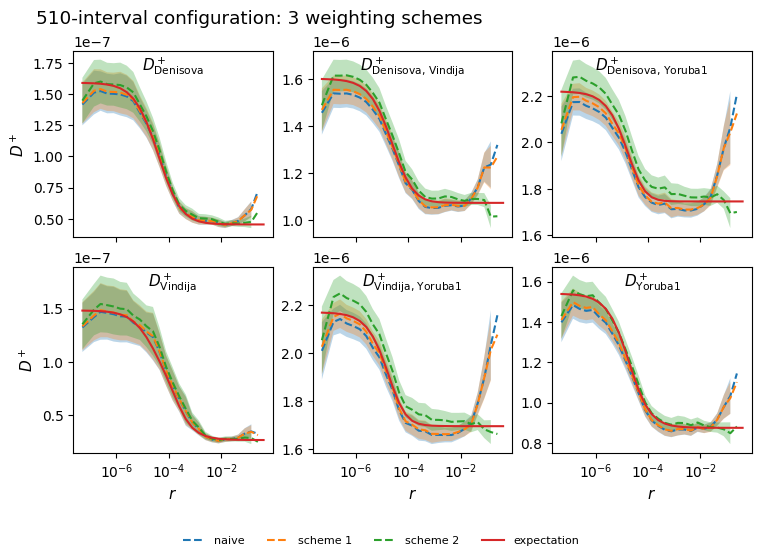

In [19]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_5_interval_config.pdf",
    title="510-interval configuration: 3 weighting schemes",
    labels=["naive", "scheme 1", "scheme 2", "expectation"],
    means=[interval_naive_ms, interval_w1_ms, interval_w2_ms],
    varcovs=[interval_naive_vcs, interval_w1_vcs, interval_w2_vcs]
)

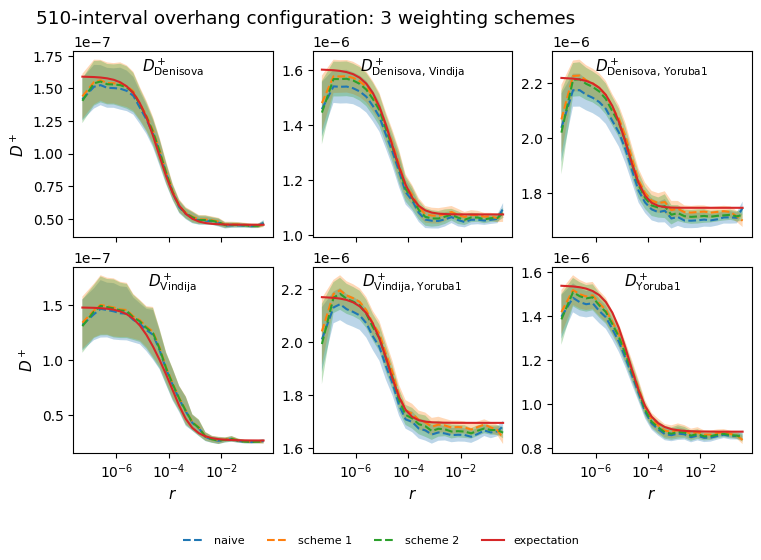

In [20]:
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    out="figures/fig_6_overhang_config.pdf",
    title="510-interval overhang configuration: 3 weighting schemes",
    labels=["naive", "scheme 1", "scheme 2", "expectation"],
    means=[overhang_naive_ms, overhang_w1_ms, overhang_w2_ms],
    varcovs=[overhang_naive_vcs, overhang_w1_vcs, overhang_w2_vcs]
)

In [34]:
def weighting_scheme_3(regions):
    """
    Compute uL * uR on each chromosome and sum them
    """
    # Construct arrays
    sums = np.array([regions[key]["sums"] for key in regions])

    factors = np.zeros(len(regions[next(iter(regions))]["denoms"]) - 1)
    for ii in range(1, 23):
        # Compute average ul * ur in each interval and bin
        _regions = {key: regions[key] for key in regions if key[0] == ii}
        denoms = np.array([_regions[key]["denoms"] for key in _regions])
        mut_facs = np.array([_regions[key]["mut_facs"] for key in _regions])
        tot_pair_count = denoms[:, :-1].sum()
        tot_ulur = mut_facs[:, :-1].sum()
        avg_ulur = tot_ulur / tot_pair_count
        # Sum ul * ur over the genome but keep bins separate
        _factors = mut_facs[:, :-1].sum(0) / avg_ulur
        factors += _factors
    factors = factors[:, None]

    raw_means = np.zeros(sums.shape[1:], dtype=np.float64)
    raw_means[:-1, :] = sums[:, :-1].sum(0) / factors
    raw_means[-1, :] = sums[:, -1].sum(0) / denoms[:, -1].sum()
    # Convert means to a list
    means = [raw_means[i] for i in range(len(raw_means))]
    return means

In [35]:
fnames = [f"data/sums/interval_overhang/interval_overhang_stats_chr{j}.pkl" for j in range(1, 23)]
regions = {}
for fname in fnames:
    with open(fname, "rb") as fin:
        chrom_sums = pickle.load(fin)
    regions.update(chrom_sums)

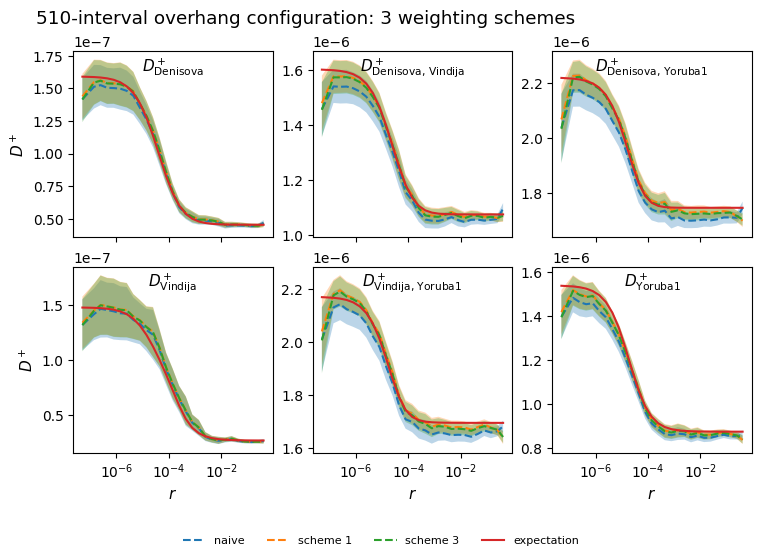

In [36]:
test_means = weighting_scheme_3(regions)
dpluspy.plotting.plot_d_plus_curves(
    models=model, 
    bins=bins, 
    pop_ids=pop_ids,
    cols=3, 
    ax_size=2.5, 
    title="510-interval overhang configuration: 3 weighting schemes",
    labels=["naive", "scheme 1", "scheme 3", "expectation"],
    means=[overhang_naive_ms, overhang_w1_ms, test_means],
    varcovs=[overhang_naive_vcs, overhang_w1_vcs, overhang_w1_vcs]
)